## Lista 04 - Redes Neurais Artificiais

### Imports

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split  

### Funções compartilhadas entre as questões

#### Ativação da camada oculta

In [130]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

#### Inicialização dos parâmetros

In [131]:
def init_params(n_input, n_hidden, n_output, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((n_hidden, n_input)) * np.sqrt(2.0 / n_input)
    b1 = np.zeros((n_hidden, 1))
    W2 = rng.standard_normal((n_output, n_hidden)) * np.sqrt(1.0 / n_hidden)
    b2 = np.zeros((n_output, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

#### Atualização dos parâmetros (SGD + Momentum)

In [132]:
def init_velocity(params):
    return {"v_" + k: np.zeros_like(v) for k, v in params.items()}

def update_params(params, grads, velocity, lr, momentum):
    for key in ["W1", "b1", "W2", "b2"]:
        velocity["v_" + key] = momentum * velocity["v_" + key] - lr * grads["d" + key]
        params[key] = params[key] + velocity["v_" + key]
    return params, velocity

#### Loop de treinamento (minibatch + early stopping)

In [133]:
def train(X_train, y_train, X_val, y_val, params, n_epochs=500, batch_size=32, lr=10**(-3), momentum=0.9, verbose=True, patience=30):
    velocity = init_velocity(params)
    n_train = X_train.shape[1]
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = np.inf
    best_params = {k: v.copy() for k, v in params.items()}
    patience_counter = 0
    rng = np.random.default_rng(0)

    for epoch in range(1, n_epochs + 1):
        idx    = rng.permutation(n_train)
        X_shuf = X_train[:, idx]
        y_shuf = y_train[:, idx]

        for start in range(0, n_train, batch_size):
            Xb = X_shuf[:, start:start + batch_size]
            yb = y_shuf[:, start:start + batch_size]
            yp, cache = forward(Xb, params)
            grads = backward(yp, yb, params, cache)
            params, velocity = update_params(params, grads, velocity, lr, momentum)

        yp_tr, _ = forward(X_train, params)
        train_loss = loss_fn(yp_tr, y_train)
        yp_vl, _ = forward(X_val, params)
        val_loss = loss_fn(yp_vl, y_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_params      = {k: v.copy() for k, v in params.items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping na época {epoch}.")
            break

        if verbose and epoch % 50 == 0:
            print(f"Época {epoch:4d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    return best_params, history

#### Normalização (z-score)

In [134]:
def normalize(X_train, X_val, X_test):
    # Normalização baseada apenas no conjunto de treino
    mu = X_train.mean(axis=0, keepdims=True)
    sigma = X_train.std(axis=0, keepdims=True) + 10**(-8)
    return (X_train - mu) / sigma, (X_val - mu) / sigma, (X_test - mu) / sigma, mu, sigma

#### Random Search

In [135]:
def random_search(X_tr, y_tr, X_vl, y_vl, n_input, n_output, n_trials=20, seed=0):
    rng = np.random.default_rng(seed)
    space = {
        "n_hidden"  : [16, 32, 64, 128, 256],
        "lr"        : [1e-2, 5e-3, 1e-3, 5e-4, 1e-4],
        "batch_size": [16, 32, 64, 128],
        "momentum"  : [0.5, 0.8, 0.9, 0.99],
    }
    results = []
    print(f"Iniciando Random Search com {n_trials} combinações...\n")
    print(f"{'Trial':>6} | {'n_hidden':>8} | {'lr':>8} | {'batch':>6} | {'momentum':>8} | {'val_loss':>10}")
    print("-" * 60)

    for trial in range(1, n_trials + 1):
        hp = {key: rng.choice(vals).item() for key, vals in space.items()}
        params = init_params(n_input, int(hp["n_hidden"]), n_output, seed=trial)
        _, history = train(X_tr, y_tr, X_vl, y_vl, params, n_epochs=300, batch_size=int(hp["batch_size"]),
            lr=float(hp["lr"]), momentum=float(hp["momentum"]), verbose=False, patience=20)
        best_val = min(history["val_loss"])
        hp["val_loss"] = best_val
        results.append(hp)
        print(f"{trial:>6} | {int(hp['n_hidden']):>8} | {hp['lr']:>8.4f} | " f"{int(hp['batch_size']):>6} | {hp['momentum']:>8.2f} | {best_val:>10.6f}")

    results.sort(key=lambda x: x["val_loss"])
    best = results[0]
    print("\n" + "-" * 60)
    print("Melhores hiperparâmetros encontrados:")
    print(f"  n_hidden={int(best['n_hidden'])}, lr={best['lr']}, "
          f"batch={int(best['batch_size'])}, momentum={best['momentum']}")
    print(f"  val_loss = {best['val_loss']:.6f}")
    print("-" * 60)
    return results, best

---
### Questão 01 — Regressão (concrete dataset)

#### Ativação de saída e funções específicas

In [136]:
def linear(z):
    return z

def linear_derivative(z):
    return np.ones_like(z)

#### Forward

In [137]:
def forward(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = linear(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

#### Função custo (MSE)

In [138]:
def loss_fn(y_pred, y_true):
    n = y_true.shape[1]
    return np.sum((y_pred - y_true) ** 2) / n

#### Backward

In [139]:
def backward(y_pred, y_true, params, cache):
    n  = y_true.shape[1]
    W2 = params["W2"]
    Z1, A1, X = cache["Z1"], cache["A1"], cache["X"]

    dA2 = (2 / n) * (y_pred - y_true)
    dZ2 = dA2 * linear_derivative(cache["Z2"])
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = dZ1 @ X.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

#### Normalização da saída

In [140]:
def normalize_y(y_train, y_val, y_test):
    mu = y_train.mean()
    sigma = y_train.std() + 1e-8
    return (y_train-mu)/sigma, (y_val-mu)/sigma, (y_test-mu)/sigma, mu, sigma

#### Métricas


In [141]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mre(y_true, y_pred):
    return np.mean((y_true - y_pred) / y_true)

def print_metrics(name, y_true, y_pred):
    print(f"  {name:12s} | RMSE: {rmse(y_true,y_pred):.4f} | "
          f"MAE: {mae(y_true,y_pred):.4f} | MRE: {mre(y_true,y_pred):.6f}")

#### Predição e gráficos

In [142]:
def predict(X, params, mu_y, sig_y):
    y_norm, _ = forward(X, params)
    return y_norm * sig_y + mu_y

def plot_results(history, y_test, y_pred_te):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Treino")
    plt.plot(epochs, history["val_loss"], linestyle="--", label="Validação")
    plt.xlabel("Época")
    plt.ylabel("MSE (normalizado)")
    plt.title("Curva de Custo — Treino vs. Validação")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_true = y_test.flatten()
    y_pred = y_pred_te.flatten()
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.5, s=20)
    plt.plot([mn, mx], [mn, mx], color="red", linestyle="--", label="Previsão")
    plt.xlabel("Real (MPa)")
    plt.ylabel("Previsto (MPa)")
    plt.title("Real vs. Previsto — Conjunto de Teste")
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Carrega e divide os dados 

In [143]:
data = np.loadtxt("concrete.csv", delimiter=",")
X_all = data[:, :-1]
y_all = data[:, -1:]

print(f"Dados: {X_all.shape[0]} amostras, {X_all.shape[1]} atributos")

X_temp, X_test, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Treino: {X_train.shape[0]} | Validação: {X_val.shape[0]} | Teste: {X_test.shape[0]}")

Dados: 1030 amostras, 8 atributos
Treino: 618 | Validação: 206 | Teste: 206


#### Normaliza e transpõe 

In [144]:
X_train_n, X_val_n, X_test_n, mu_X, sig_X = normalize(X_train, X_val, X_test)
y_train_n, y_val_n, y_test_n, mu_y, sig_y = normalize_y(y_train, y_val, y_test)

X_tr = X_train_n.T;  X_vl = X_val_n.T;  X_te = X_test_n.T
y_tr = y_train_n.T;  y_vl = y_val_n.T;  y_te = y_test_n.T

print("Shapes — X_tr:", X_tr.shape, "| y_tr:", y_tr.shape)

Shapes — X_tr: (8, 618) | y_tr: (1, 618)


#### Random Search 

In [145]:
rs_results_q1, best_hp_q1 = random_search( X_tr, y_tr, X_vl, y_vl, n_input=X_tr.shape[0], n_output=1, n_trials=20, seed=42)

Iniciando Random Search com 20 combinações...

 Trial | n_hidden |       lr |  batch | momentum |   val_loss
------------------------------------------------------------
     1 |       16 |   0.0005 |     64 |     0.80 |   0.208751
     2 |       64 |   0.0001 |     16 |     0.90 |   0.190842
     3 |       32 |   0.0100 |     64 |     0.99 |   0.146141
     4 |      128 |   0.0005 |     64 |     0.99 |   0.162340
     5 |       64 |   0.0100 |    128 |     0.80 |   0.125035
     6 |       64 |   0.0050 |     16 |     0.99 |   0.111471
     7 |      128 |   0.0005 |     32 |     0.99 |   0.121259
     8 |       64 |   0.0010 |     32 |     0.50 |   0.194334
     9 |       16 |   0.0010 |    128 |     0.50 |   0.411999
    10 |      256 |   0.0001 |     32 |     0.90 |   0.188664
    11 |       16 |   0.0005 |     64 |     0.80 |   0.282214
    12 |       16 |   0.0001 |     32 |     0.99 |   0.141210
    13 |      128 |   0.0005 |    128 |     0.50 |   0.256796
    14 |       32 |   0.

#### Treino final

In [146]:
params_q1 = init_params(n_input=X_tr.shape[0], n_hidden=int(best_hp_q1["n_hidden"]), n_output=1, seed=42)

best_params_q1, history_q1 = train(X_tr, y_tr, X_vl, y_vl, params_q1, n_epochs=1000, batch_size=int(best_hp_q1["batch_size"]),
    lr=float(best_hp_q1["lr"]), momentum=float(best_hp_q1["momentum"]), verbose=True, patience=50)

Época   50 | Train: 0.1041 | Val: 0.1557
Época  100 | Train: 0.1038 | Val: 0.1613
Época  150 | Train: 0.0727 | Val: 0.1380
Early stopping na época 184.


#### Métricas e gráficos

Métricas Q1 (escala original — MPa):
  Treino       | RMSE: 4.3727 | MAE: 3.4152 | MRE: -0.019414
  Validação    | RMSE: 5.8986 | MAE: 4.1468 | MRE: -0.014739
  Teste        | RMSE: 5.9396 | MAE: 4.5865 | MRE: 0.003191


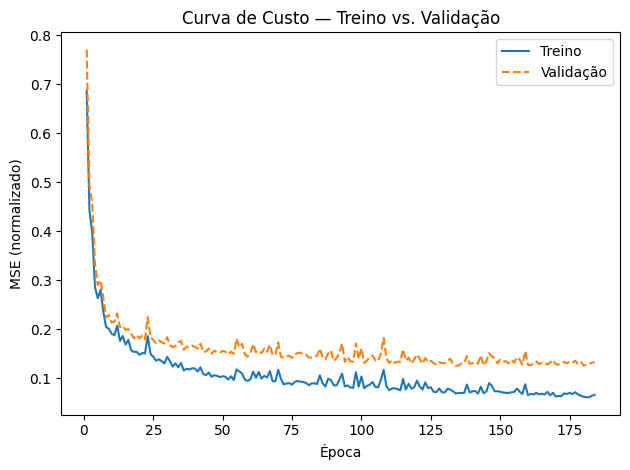

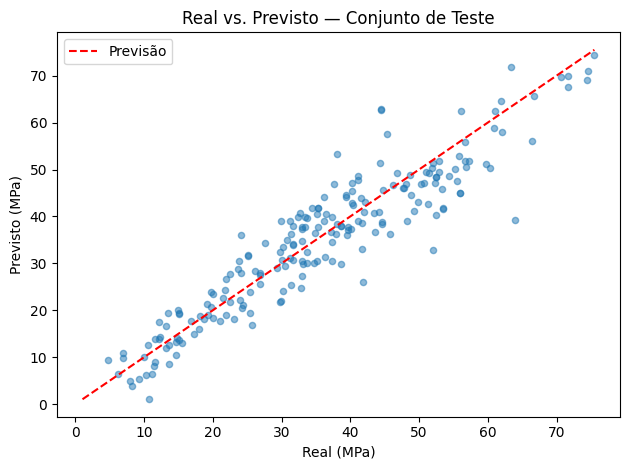

In [147]:
y_pred_tr_q1 = predict(X_tr, best_params_q1, mu_y, sig_y)
y_pred_vl_q1 = predict(X_vl, best_params_q1, mu_y, sig_y)
y_pred_te_q1 = predict(X_te, best_params_q1, mu_y, sig_y)

print("Métricas Q1 (escala original — MPa):")
print_metrics("Treino",    y_train.T, y_pred_tr_q1)
print_metrics("Validação", y_val.T,   y_pred_vl_q1)
print_metrics("Teste",     y_test.T,  y_pred_te_q1)

plot_results(history_q1, y_test, y_pred_te_q1)

---
### Questão 02 — Classificação (vehicle dataset)

#### Ativação de saída e funções específicas

In [148]:
def softmax(z):
    z_stable = z - z.max(axis=0, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / exp_z.sum(axis=0, keepdims=True)

#### Forward (saída softmax)

In [149]:
def forward(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = softmax(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

#### Função custo (Cross-Entropy)

In [150]:
def loss_fn(y_pred, y_onehot):
    n = y_onehot.shape[1]
    return -np.sum(y_onehot * np.log(np.clip(y_pred, 1e-12, 1.0))) / n

#### Backward Q2

In [151]:
def backward(y_pred, y_onehot, params, cache):
    n = y_onehot.shape[1]
    W2 = params["W2"]
    Z1, A1, X = cache["Z1"], cache["A1"], cache["X"]

    dZ2 = (y_pred - y_onehot) / n
    dW2 = dZ2 @ A1.T
    db2 = np.sum(dZ2, axis=1, keepdims=True)

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = dZ1 @ X.T
    db1 = np.sum(dZ1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

#### Codificação one-hot

In [152]:
def to_onehot(y_idx, n_classes):
    oh = np.zeros((n_classes, len(y_idx)))
    oh[y_idx, np.arange(len(y_idx))] = 1.0
    return oh

#### Métricas

In [153]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_recall_f1_macro(y_true, y_pred, n_classes):
    precs, recs = [], []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        precs.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
        recs.append(tp  / (tp + fn) if (tp + fn) > 0 else 0.0)
    p, r = np.mean(precs), np.mean(recs)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def print_metrics(name, y_true, y_pred, n_classes):
    acc = accuracy(y_true, y_pred)
    p, r, f1 = precision_recall_f1_macro(y_true, y_pred, n_classes)
    print(f"{name:12s} | Acurácia: {acc:.4f} | Precisão: {p:.4f} | "
          f"Revocação: {r:.4f} | F1: {f1:.4f}")

#### Predição e gráficos

In [154]:
def predict_classes(X, params):
    probs, _ = forward(X, params)
    return np.argmax(probs, axis=0)

def plot_results(history, y_test_idx, y_pred_te_idx, class_names):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Treino")
    plt.plot(epochs, history["val_loss"], linestyle="--", label="Validação")
    plt.xlabel("Época")
    plt.ylabel("Cross-Entropy")
    plt.title("Curva de Custo — Treino vs. Validação")
    plt.legend()
    plt.tight_layout()
    plt.show()

    n_classes = len(class_names)
    cm = confusion_matrix(y_test_idx, y_pred_te_idx, n_classes)
    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(np.arange(n_classes), class_names)
    plt.yticks(np.arange(n_classes), class_names)
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão — Conjunto de Teste")
    for i in range(n_classes):
        for j in range(n_classes):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.show()

#### Carrega e divide os dados 

In [155]:
data = np.loadtxt("vehicle.csv", delimiter=",")
X_all_q2 = data[:, :-1]
y_all_idx= data[:, -1].astype(int)   # 0=bus, 1=opel, 2=saab, 3=van

class_names = ["bus", "opel", "saab", "van"]
n_classes = len(class_names)

print(f"Dados: {X_all_q2.shape[0]} amostras, {X_all_q2.shape[1]} atributos | Classes: {class_names}")
print("Distribuição:", {class_names[c]: int(np.sum(y_all_idx == c)) for c in range(n_classes)})

X_temp, X_test_q2, y_temp, y_test_idx = train_test_split(
    X_all_q2, y_all_idx, test_size=0.20, random_state=42, stratify=y_all_idx)
X_train_q2, X_val_q2, y_train_idx, y_val_idx = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Treino: {X_train_q2.shape[0]} | Validação: {X_val_q2.shape[0]} | Teste: {X_test_q2.shape[0]}")

Dados: 846 amostras, 18 atributos | Classes: ['bus', 'opel', 'saab', 'van']
Distribuição: {'bus': 218, 'opel': 212, 'saab': 217, 'van': 199}
Treino: 507 | Validação: 169 | Teste: 170


#### Normaliza e transpõe — Q2

In [156]:
X_train_n2, X_val_n2, X_test_n2, mu_X2, sig_X2 = normalize(X_train_q2, X_val_q2, X_test_q2)

X_tr2 = X_train_n2.T;  X_vl2 = X_val_n2.T;  X_te2 = X_test_n2.T
y_tr2 = to_onehot(y_train_idx, n_classes)
y_vl2 = to_onehot(y_val_idx,   n_classes)
y_te2 = to_onehot(y_test_idx,  n_classes)

print("Shapes — X_tr2:", X_tr2.shape, "| y_tr2:", y_tr2.shape)

Shapes — X_tr2: (18, 507) | y_tr2: (4, 507)


#### Random Search — Q2

In [157]:
rs_results_q2, best_hp_q2 = random_search(X_tr2, y_tr2, X_vl2, y_vl2, n_input=X_tr2.shape[0], n_output=n_classes, n_trials=20, seed=42,)

Iniciando Random Search com 20 combinações...

 Trial | n_hidden |       lr |  batch | momentum |   val_loss
------------------------------------------------------------
     1 |       16 |   0.0005 |     64 |     0.80 |   0.937290
     2 |       64 |   0.0001 |     16 |     0.90 |   0.664512
     3 |       32 |   0.0100 |     64 |     0.99 |   0.372744
     4 |      128 |   0.0005 |     64 |     0.99 |   0.422301
     5 |       64 |   0.0100 |    128 |     0.80 |   0.458581
     6 |       64 |   0.0050 |     16 |     0.99 |   0.406622
     7 |      128 |   0.0005 |     32 |     0.99 |   0.379242
     8 |       64 |   0.0010 |     32 |     0.50 |   0.646845
     9 |       16 |   0.0010 |    128 |     0.50 |   1.190016
    10 |      256 |   0.0001 |     32 |     0.90 |   0.585163
    11 |       16 |   0.0005 |     64 |     0.80 |   0.950838
    12 |       16 |   0.0001 |     32 |     0.99 |   0.495219
    13 |      128 |   0.0005 |    128 |     0.50 |   0.953692
    14 |       32 |   0.

#### Treino final 

In [158]:
params_q2 = init_params( n_input=X_tr2.shape[0], n_hidden=int(best_hp_q2["n_hidden"]), n_output=n_classes, seed=42)

best_params_q2, history_q2 = train( X_tr2, y_tr2, X_vl2, y_vl2, params_q2, n_epochs=1000, batch_size=int(best_hp_q2["batch_size"]), 
    lr=float(best_hp_q2["lr"]), momentum=float(best_hp_q2["momentum"]), verbose=True, patience=50)

Época   50 | Train: 0.1686 | Val: 0.4689
Early stopping na época 72.


#### Métricas e gráficos

Métricas Q2:
Treino       | Acurácia: 0.8442 | Precisão: 0.8518 | Revocação: 0.8462 | F1: 0.8490
Validação    | Acurácia: 0.8047 | Precisão: 0.8174 | Revocação: 0.8039 | F1: 0.8106
Teste        | Acurácia: 0.7765 | Precisão: 0.7890 | Revocação: 0.7754 | F1: 0.7821


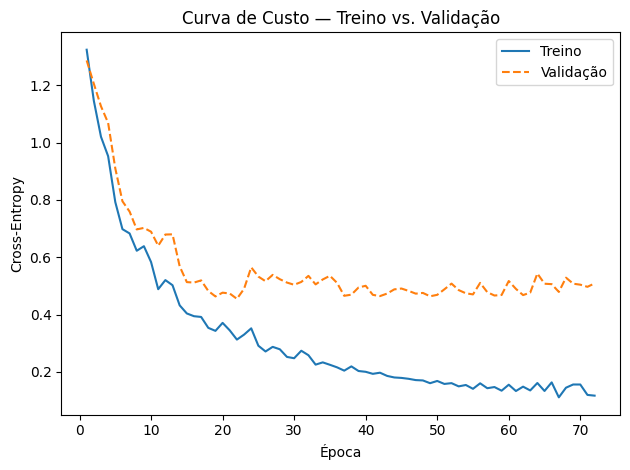

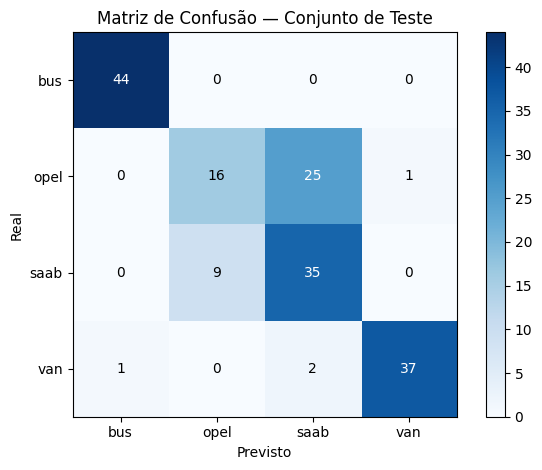

In [159]:
y_pred_tr_q2 = predict_classes(X_tr2, best_params_q2)
y_pred_vl_q2 = predict_classes(X_vl2, best_params_q2)
y_pred_te_q2 = predict_classes(X_te2, best_params_q2)

print("Métricas Q2:")
print_metrics("Treino",    y_train_idx, y_pred_tr_q2, n_classes)
print_metrics("Validação", y_val_idx,   y_pred_vl_q2, n_classes)
print_metrics("Teste",     y_test_idx,  y_pred_te_q2, n_classes)

plot_results(history_q2, y_test_idx, y_pred_te_q2, class_names)